/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Hamiltonian-ODE Dynamic Graph Learning (ArXiv Author-Paper)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
3. 著者データの整形中...
✓ 前処理完了: 26358 件

[Filtering] 論文を 10 本以上書いている著者を抽出中...
  Total Authors: 81627 -> Active Authors: 862
  (削減率: 98.9%)
  Valid Papers: 26358 -> 8244 (著者が残った論文のみ)
Building graphs for 7 years...

[Graph Info]
  Total Nodes: 9106
  Authors:     862
  Papers:      8244
  Input Dim:   1024
  Years:       [2020, 2021, 2022, 2023, 2024, 2025, 2026]
Initializing author vectors with paper means...

>>> Training Started...
Epoch 01 | Loss: 46.8370 | MRR: 0.0482 | Consist: 0.971
Epoch 02 | Loss: 39.7477 | MRR: 0.0700 | Consist: 0.978
Epoch 03 | Loss: 39.5380 | MRR: 0.0604 | Consist: 0.980
Epoch 04 | Loss: 37.2691 | MRR: 0.0602 | Consist: 0.987
Epoch 05 | Loss: 36.2376 | MRR: 0.0553 | Consist: 0.987
Epoch 06 | Loss: 37.1134 | MRR: 0.0573 | Consist: 0.983
Epoch 07 | Loss: 36.6389 | MRR: 0.0548 | Consist: 0.985
Epoch 08 | Loss: 36.2530 | MRR: 0.0621 | Consist: 0.985
Epoch 09 | Loss: 36.4725 | 

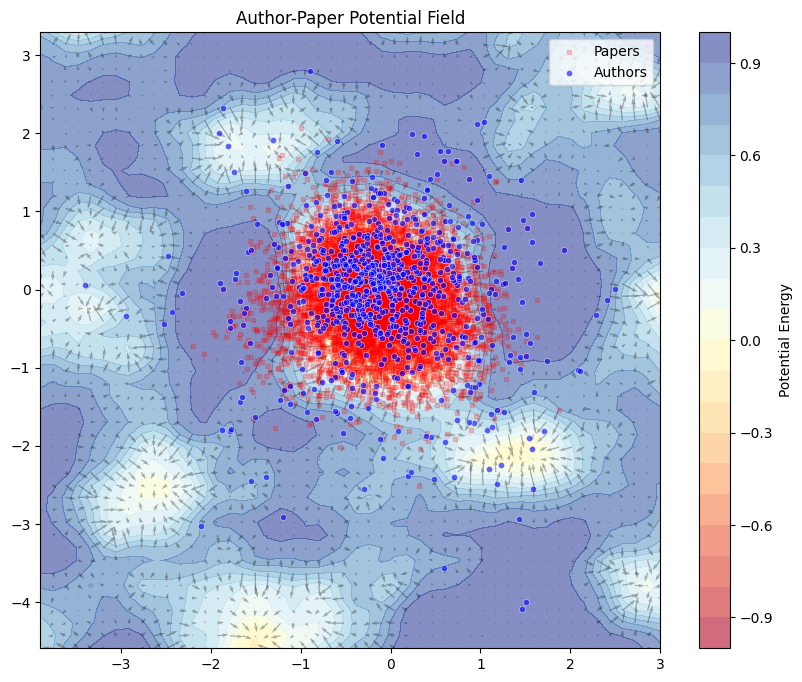

In [1]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            # 改行やカンマの表記揺れに対応してクリーニング
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            # 空白区切りで数値化
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_arxiv_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    embeddings = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        
        if desc is not None and len(desc) > 0:
            embeddings.append(desc)
            valid_indices.append(i)

    if not embeddings:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['paper_vector'] = embeddings

    print("3. 著者データの整形中...")
    # 著者名の文字列 "Author A, Author B" をリスト ["Author A", "Author B"] に変換
    def parse_authors(x):
        if isinstance(x, str):
            # カンマで分割し、前後の空白を除去
            return [a.strip() for a in x.split(',')]
        return []

    df['authors_list'] = df['authors'].fillna("").apply(parse_authors)

    # 念のため年でフィルタリング（2020-2026）
    if 'year' in df.columns:
        df = df[(df['year'] >= 2020) & (df['year'] <= 2026)]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def filter_active_authors(df, min_papers=10):
    """
    指定した本数以上の論文を書いている著者のみを残すフィルタリング関数
    """
    print(f"\n[Filtering] 論文を {min_papers} 本以上書いている著者を抽出中...")
    
    # 1. 全著者の出現回数をカウント
    all_authors_flat = [a for sublist in df['authors_list'] for a in sublist]
    author_counts = Counter(all_authors_flat)
    
    total_authors = len(author_counts)
    
    # 2. 条件を満たす著者セットを作成
    active_authors = {a for a, c in author_counts.items() if c >= min_papers}
    
    print(f"  Total Authors: {total_authors} -> Active Authors: {len(active_authors)}")
    print(f"  (削減率: {100 * (1 - len(active_authors)/total_authors):.1f}%)")
    
    # 3. DataFrame内の著者リストを更新（アクティブな著者だけ残す）
    def filter_row(auth_list):
        return [a for a in auth_list if a in active_authors]
    
    df['authors_list'] = df['authors_list'].apply(filter_row)
    
    # 4. 著者が0人になってしまった論文（マイナーな著者しかいない論文）を除外
    original_len = len(df)
    df = df[df['authors_list'].map(len) > 0].copy()
    
    print(f"  Valid Papers: {original_len} -> {len(df)} (著者が残った論文のみ)")
    
    return df

# === 初期化とグラフ構築関数 ===

def calculate_initial_author_vectors(df, num_authors, input_dim, all_authors):
    """
    著者の初期ベクトルを、その人が書いた論文ベクトルの平均で計算する
    """
    print("Initializing author vectors with paper means...")
    author_vectors = np.zeros((num_authors, input_dim), dtype=np.float32)
    author_counts = np.zeros(num_authors, dtype=np.float32)
    
    # Author名 -> Index のマップ
    author_to_idx = {a: i for i, a in enumerate(all_authors)}
    
    for _, row in df.iterrows():
        vec = row['paper_vector']
        if vec is None or len(vec) != input_dim: continue
        
        authors = row['authors_list']
        for a in authors:
            if a in author_to_idx:
                idx = author_to_idx[a]
                author_vectors[idx] += vec
                author_counts[idx] += 1
    
    # 平均化
    for i in range(num_authors):
        if author_counts[i] > 0:
            author_vectors[i] /= author_counts[i]
        else:
            # 論文データがない著者はランダム初期化
            author_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(author_vectors, dtype=torch.float32)

def build_author_paper_graphs(df):
    """
    著者(Author) - 論文(Paper) のグラフを構築する
    """
    # 全著者と全論文(URLをIDとする)のリスト作成
    all_authors = sorted(list(set([a for auths in df['authors_list'] for a in auths])))
    all_papers = sorted(df['url'].unique().tolist())
    
    # IDマップ作成
    author_to_idx = {auth: i for i, auth in enumerate(all_authors)}
    # 論文IDは、著者の後ろに追加する
    paper_to_idx = {url: i + len(all_authors) for i, url in enumerate(all_papers)}
    
    total_nodes = len(all_authors) + len(all_papers)
    
    # 論文の特徴量辞書を作成
    paper_features = {}
    for _, row in df.iterrows():
        paper_features[row['url']] = row['paper_vector']
    
    # 特徴量の次元数を取得
    input_dim = len(next(iter(paper_features.values()))) if paper_features else 768

    global_graph_dict = {}
    
    # 'year' カラムでグルーピングして年ごとのグラフを作る
    year_groups = df.groupby('year')
    all_historical_edges = set()
    
    print(f"Building graphs for {len(year_groups)} years...")

    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            url = row['url']
            if url not in paper_to_idx: continue
            p_idx = paper_to_idx[url]
            
            # 著者と論文をつなぐ
            for auth in row['authors_list']:
                if auth in author_to_idx:
                    a_idx = author_to_idx[auth]
                    
                    # 双方向エッジ (Author <-> Paper)
                    edges.append([a_idx, p_idx]) 
                    edges.append([p_idx, a_idx])
                    
                    # 履歴用には Author -> Paper の向きだけ記録
                    all_historical_edges.add((a_idx, p_idx))
        
        if not edges: continue
        
        # ノード特徴行列の初期化 (著者は0, 論文はベクトル)
        x = torch.zeros(total_nodes, input_dim)
        for url, p_idx in paper_to_idx.items():
            if url in paper_features: 
                x[p_idx] = torch.tensor(paper_features[url])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        
        # その年に登場したノードのマスク
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        # Dataオブジェクト作成
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_authors, all_papers, total_nodes, all_historical_edges, input_dim

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)
    
class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_authors = num_authors
        self.latent_dim = latent_dim
        
        # 著者埋め込み
        self.author_embeddings = nn.Embedding(num_authors, input_dim)
        nn.init.normal_(self.author_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        author_idx = node_indices[node_indices < self.num_authors]
        if author_idx.numel() > 0:
            features[author_idx] = self.author_embeddings(author_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3. 4つのモデル定義
# ============================================================
# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_authors, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_authors, input_dim, hidden_dim, latent_dim)
        # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_authors, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_authors, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 著者->論文のエッジ
    mask = (pos_edge_index[0] < num_authors) & (pos_edge_index[1] >= num_authors)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_authors, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_authors, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_authors'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_authors'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_authors, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_author_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_authors = num_authors
        self.latent_dim = latent_dim
        
        # 著者用埋め込み設定
        self.author_embeddings = nn.Embedding(num_authors, input_dim)
        if initial_author_vectors is not None:
            # 計算済みの平均ベクトルで初期化
            self.author_embeddings.weight.data.copy_(initial_author_vectors)
        else:
            nn.init.normal_(self.author_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        author_idx = node_indices[node_indices < self.num_authors]
        if author_idx.numel() > 0:
            features[author_idx] = self.author_embeddings(author_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_authors, active_papers, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_authors) == 0 or len(active_papers) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_a = active_authors[torch.randint(0, len(active_authors), (num_samples * 5,))]
    cand_p = active_papers[torch.randint(0, len(active_papers), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_a] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        a, p = cand_a[idx].item(), cand_p[idx].item()
        edge = (a, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([a, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_authors, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0,
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.1, repulsion_weight=5.0):
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    paper_mask = (node_indices >= num_authors) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_authors = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_authors])
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_authors, active_papers, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_a_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_authors])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_authors])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_a_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (論文間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_papers = z_t[paper_mask]
    if z_papers.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_papers.size(0))[:200]
        z_sub = z_papers[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_authors, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 著者 -> 論文 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_authors) & (pos_edge_index[1] >= num_authors)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_papers = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_authors])
    if len(active_papers) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_papers[torch.randint(len(active_papers), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_authors, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_authors, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_authors, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_authors, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_a = z_np[:num_authors]
    z_p = z_np[num_authors:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Papers')
    ax.scatter(z_a[:, 0], z_a[:, 1], c='blue', marker='o', s=20, edgecolors='white', linewidth=0.5, alpha=0.6, label='Authors')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_authors, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0, edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 論文 (赤/正方形)
    z_p = z_np[num_authors:]
    pot_p = potentials_nodes[num_authors:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Papers')

    # 著者 (青/円)
    z_a = z_np[:num_authors]
    pot_a = potentials_nodes[:num_authors]
    ax.scatter(z_a[:, 0], z_a[:, 1], pot_a, c='blue', marker='o', s=20, edgecolors='white', linewidth=0.5, alpha=0.6, label='Authors')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (ArXiv Author-Paper)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_arxiv_data('../dataset/arxiv_cs_Data/arxiv_cs_embedded_2020-2026.csv')
    if len(df) == 0: exit()

    # 10本以上論文を書いている著者のみに絞る
    df = filter_active_authors(df, min_papers=10)
    
    if len(df) > 0:
        # 2. グラフ構築
        graphs, authors, papers, total_n, hist_edges, in_dim = build_author_paper_graphs(df)
        num_authors = len(authors)
        
        print(f"\n[Graph Info]")
        print(f"  Total Nodes: {total_n}")
        print(f"  Authors:     {num_authors}")
        print(f"  Papers:      {len(papers)}")
        print(f"  Input Dim:   {in_dim}")
        print(f"  Years:       {list(graphs.keys())}")

        # 3. 著者の初期ベクトル計算
        init_vectors = calculate_initial_author_vectors(df, num_authors, in_dim, authors)

        # 4. モデル初期化
        model = UnifiedVGAE(
            num_nodes=total_n, 
            num_authors=num_authors, 
            input_dim=in_dim,
            hidden_dim=128, 
            latent_dim=2, 
            initial_author_vectors=init_vectors
        ).to(device)

        # 5. 学習開始
        print("\n>>> Training Started...")
        model, best_mrr, history = train_model_improved(
            model, graphs, num_authors, hist_edges, num_epochs=15
        )
        
        print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")

        # 6. 可視化 (2Dポテンシャル場)
        last_year = max(graphs.keys())
        print(f"\n[Visualization] Year: {last_year}")
        
        # 可視化実行
        visualize_potential_landscape_2d(model, graphs[last_year], num_authors, device, title="Author-Paper Potential Field")
    else:
        print("データ不足のため終了します。")

Nature-style Benchmarking (ArXiv Author-Paper Dynamics)
Static vs VGRNN vs GODE vs P-NODE

>>> Starting Multi-run Training...
Starting comparison with 10 runs (Including Static)...

--- Run 1/10 ---
  [Static] Run 1 Time:  1.36s | Final AUC: 0.4855 | MRR: 0.0288
  [VGRNN] Run 1 Time:  2.42s | Final AUC: 0.5000 | MRR: 0.9944
  [StandardGODE] Run 1 Time:  1.70s | Final AUC: 0.4679 | MRR: 0.0304
  [P-NODE] Run 1 Time:  1.87s | Final AUC: 0.5077 | MRR: 0.0341

--- Run 2/10 ---
  [Static] Run 2 Time:  1.35s | Final AUC: 0.4851 | MRR: 0.0273
  [VGRNN] Run 2 Time:  2.40s | Final AUC: 0.4473 | MRR: 0.0231
  [StandardGODE] Run 2 Time:  1.69s | Final AUC: 0.4597 | MRR: 0.0282
  [P-NODE] Run 2 Time:  1.87s | Final AUC: 0.4706 | MRR: 0.0303

--- Run 3/10 ---
  [Static] Run 3 Time:  1.35s | Final AUC: 0.4239 | MRR: 0.0246
  [VGRNN] Run 3 Time:  2.41s | Final AUC: 0.4660 | MRR: 0.0238
  [StandardGODE] Run 3 Time:  1.69s | Final AUC: 0.4558 | MRR: 0.0272
  [P-NODE] Run 3 Time:  1.87s | Final AUC: 0.5

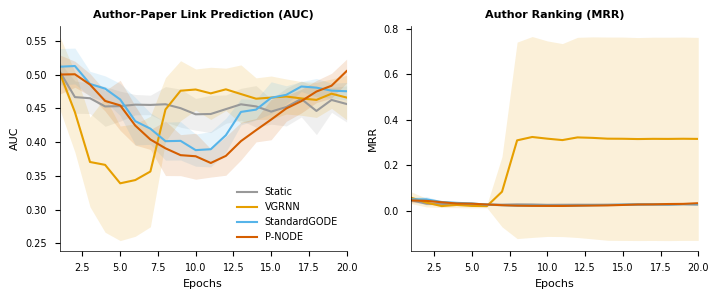

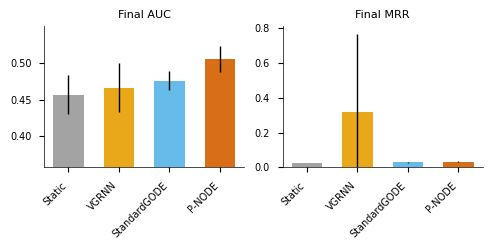

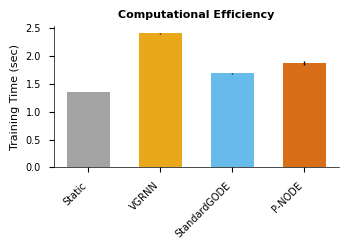


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Significance Test Results:
  Metric              Comparison   p-value Significance
0    auc        P-NODE vs Static  3.42e-04          ***
1    auc         P-NODE vs VGRNN  7.15e-03           **
2    auc  P-NODE vs StandardGODE  8.04e-04          ***
3    mrr        P-NODE vs Static  2.29e-07          ***
4    mrr         P-NODE vs VGRNN  8.99e-02           ns
5    mrr  P-NODE vs StandardGODE  4.44e-05          ***


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns
import time

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    """Nature投稿用のプロットスタイル設定"""
    plt.style.use('seaborn-v0_8-paper')
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 2.5), # 89mm幅 (Single Column)
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

# カラーパレット (Static入りの構成)
NATURE_COLORS = {
    "Static": "#999999",       # グレー (Baseline)
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"        # バーミリオン (提案手法・強調)
}

# ============================================================
# 1. 複数試行対応の学習関数 (Static対応版)
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    Staticを含む4手法で比較実験を行う関数
    著者-論文の動的グラフ学習に対応
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    final_scores = {name: {'auc': [], 'mrr': []} for name in models.keys()}
    all_histories = {name: [] for name in models.keys()}
    training_times = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs (Including Static)...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            model = model_cls(config['total_n'], config['num_authors'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            start_time = time.time()

            # --- Training Loop ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    # 履歴作成
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Reconstruction Loss
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Prediction Loss (Static以外)
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential Loss (P-NODEのみ)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_authors'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            end_time = time.time()
            elapsed_time = end_time - start_time
            training_times[name].append(elapsed_time)

            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            all_histories[name].append(run_history)
            
            print(f"  [{name}] Run {run+1} Time: {elapsed_time: .2f}s | Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories, training_times

# ============================================================
# 2. 統計的有意差検定
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    metrics = ['auc', 'mrr']
    results_text = []
    
    for metric in metrics:
        proposed_vals = final_scores[proposed_name][metric]
        for name in final_scores.keys():
            if name == proposed_name: continue
            
            target_vals = final_scores[name][metric]
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': f"{p_val:.2e}",
                'Significance': sig
            })
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Functions
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    metrics = ['auc', 'mrr']
    titles = ['Author-Paper Link Prediction (AUC)', 'Author Ranking (MRR)']
    
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0)) # Double Column Width
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for name, runs in all_histories.items():
            matrix = np.array([h[metric] for h in runs])
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        if i == 0: ax.legend(frameon=False, loc='lower right')
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', dpi=300)
    plt.show()

def plot_significance_bars(final_scores):
    set_nature_style()
    metrics = ['auc', 'mrr']
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, 
               ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        
        min_val = min(means) - max(stds)*3
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.show()

def plot_time_comparison(training_times):
    set_nature_style()
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    
    names = list(training_times.keys())
    means = [np.mean(training_times[n]) for n in names]
    stds = [np.std(training_times[n]) for n in names]
    
    x_pos = np.arange(len(names))
    colors = [NATURE_COLORS[n] for n in names]
    
    bars = ax.bar(x_pos, means, yerr=stds, align='center', 
                  alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Training Time (sec)')
    ax.set_title('Computational Efficiency', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('./outputs/nature_training_time.pdf', dpi=300)
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if not os.path.exists('./outputs'): os.makedirs('./outputs')
    print("=" * 60)
    print("Nature-style Benchmarking (ArXiv Author-Paper Dynamics)")
    print("Static vs VGRNN vs GODE vs P-NODE")
    print("=" * 60)

    # 1. Config構築 (前段のコードで graphs 等が生成されている前提)
    # もし変数が消えている場合は前段の `build_author_paper_graphs` を再実行してください
    if 'graphs' in locals():
        config = {
            'graphs': graphs,
            'total_n': total_n,
            'num_authors': num_authors,  # num_corps -> num_authors に変更
            'in_dim': in_dim
        }
        
        # 2. 実験実行
        print("\n>>> Starting Multi-run Training...")
        final_scores, all_histories, training_times = train_multiple_runs(
            config, 
            num_runs=10,     # 論文用なら5~10回推奨
            num_epochs=20, 
            latent_dim=16, 
            hidden_dim=128
        )
        
        # 3. プロット生成
        print("\n>>> Generating Nature-style Plots...")
        plot_nature_comparison(all_histories)
        plot_significance_bars(final_scores)
        plot_time_comparison(training_times)
        
        # 4. 統計検定結果
        df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
        print("\nSignificance Test Results:")
        print(df_sig)
        
    else:
        print("エラー: グラフデータが見つかりません。")
        print("前段の `build_author_paper_graphs` を実行して `graphs` 変数を生成してください。")

Visualizing Year: 2026


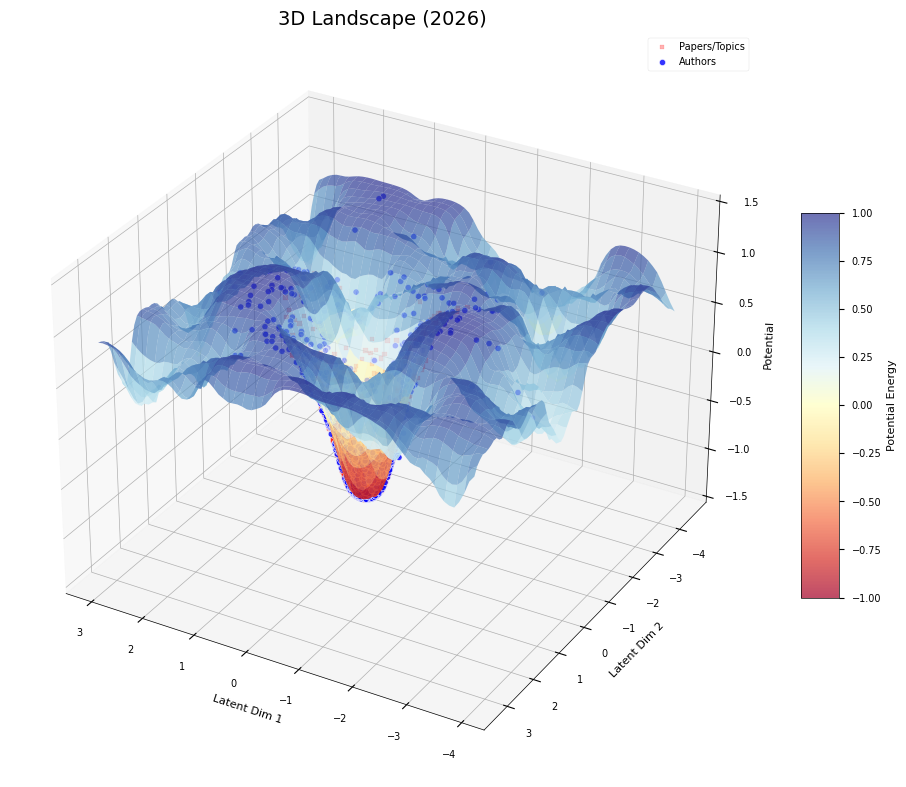

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

# ============================================================
# 3D可視化関数の定義 (このセルで再定義しておくと確実です)
# ============================================================
def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    model.eval()
    data = data.to(device)
    
    # 1. 潜在変数の取得
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. 表示範囲の決定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 3. グリッドデータの作成 (高解像度)
    # モデル内の potential_net を使って地形を計算
    if hasattr(model, 'temporal_predictor'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: PotentialNet not found.")
        return

    X, Y, Z = pot_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 4. プロット
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 地形 (Surface)
    # cmap='RdYlBu' : 青が低い(安定)、赤が高い(不安定)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0, 
                           edgecolor='none', alpha=0.7)
    
    # カラーバー
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Potential Energy')

    # 5. ノードのプロット (高さはポテンシャル値に合わせる)
    with torch.no_grad():
        potentials_nodes = pot_net(z).cpu().numpy().flatten()
    
    # 論文/特許 (Paper/Patent) -> 赤い四角
    # num_corps (num_authors) 以降のインデックス
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    
    # 数が多い場合はサンプリング (描画負荷軽減)
    if len(z_p) > 1000:
        idx = np.random.choice(len(z_p), 1000, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, 
               alpha=0.3, label='Papers/Topics', depthshade=True)

    # 著者/企業 (Author/Corp) -> 青い丸
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    
    if len(z_c) > 1000:
        idx = np.random.choice(len(z_c), 1000, replace=False)
        z_c = z_c[idx]
        pot_c = pot_c[idx]

    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, 
               edgecolors='white', linewidth=0.5, alpha=0.8, 
               label='Authors', depthshade=True)

    # ラベルと視点
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    ax.set_zlim(-1.5, 1.5) # Z軸の範囲固定
    
    # 視点変更 (仰角30度, 方位角120度)
    ax.view_init(elev=30, azim=120)
    plt.legend()
    plt.show()

# ============================================================
# 実行ブロック
# ============================================================
# 直前の学習セルで作成された変数が存在するか確認してから実行
if 'model' in locals() and 'graphs' in locals():
    # 最後の年を取得
    target_year = max(graphs.keys())
    print(f"Visualizing Year: {target_year}")
    
    # num_authors変数がなければ num_corps を使う（変数名の互換性）
    n_authors = num_authors if 'num_authors' in locals() else config['num_corps']
    
    visualize_potential_landscape_3d(
        model, 
        graphs[target_year], 
        n_authors, 
        device, 
        title=f"3D Landscape ({target_year})"
    )
else:
    print("エラー: 学習済みモデル 'model' やグラフデータ 'graphs' が見つかりません。")
    print("先に学習を実行してください。")


[Evaluation] Verifying Attractor Validity (Potential vs Density)...
Evaluation plot saved to ./outputs/
Correlation: -0.9397 (Expected: Negative)


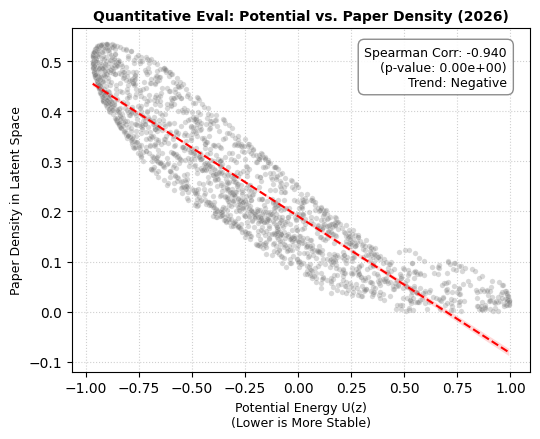

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_quantitative_correlation(model, config, num_authors, device, year_idx=-1):
    """
    ポテンシャル場と論文密度の相関を定量評価
    
    理論的予測: ポテンシャルが低い領域ほど論文密度が高い（負の相関）
    これは物理系におけるアトラクター（安定点）の妥当性を示す
    
    Args:
        model: 学習済みモデル（UnifiedVGAE or ProposedPotentialODE）
        config: グラフデータを含む設定辞書
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス（デフォルト: -1 = 最新年）
    """
    # スタイル設定（英語論文仕様）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (Potential vs Density)...")
    
    # 1. データ準備 (指定された年のグラフを取得)
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: PotentialNet not found.")
        return

    # 2. 潜在変数とポテンシャル値の計算
    with torch.no_grad():
        # 次元の不整合があれば補正
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 3. 論文(Paper)ノードの抽出
    # num_authors 以降が Paper ノード
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # データが少なすぎる場合のガード
    if len(paper_z) < 10:
        print("Not enough paper nodes for density estimation.")
        return

    # 4. 密度推定 (KDE)
    # 高次元だと計算できないためPCAで2次元に落としてから密度を計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        # 転置して (2, N) の形にする
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"KDE Error: {e}")
        return

    # 5. 相関計算 (Spearman)
    # 理論通りなら「負の相関」になるはず（ポテンシャルが低いほど密度が高い）
    corr, p_value = spearmanr(paper_potentials, densities)
    
    # 6. プロット
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    # 描画負荷軽減のためのサンプリング
    if len(paper_potentials) > 2000:
        idx = np.random.choice(len(paper_potentials), 2000, replace=False)
        plot_x = paper_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = paper_potentials
        plot_y = densities
        alpha_val = 0.5
        
    # 散布図
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', 
               edgecolors='white', linewidth=0.3, label='Papers')
    
    # 回帰直線 (トレンドライン)
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # ラベル設定
    ax.set_title(f"Quantitative Eval: Potential vs. Paper Density ({target_year})", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Paper Density in Latent Space", fontsize=9)
    
    # 統計量テキスト表示
    correlation_text = "Negative" if corr < 0 else "Positive"
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n"
                  f"Trend: {correlation_text}")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # 保存
    plt.savefig('./outputs/quantitative_eval_arxiv.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/quantitative_eval_arxiv.png', dpi=300)

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f} (Expected: Negative)")
    plt.show()

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    if 'model' in locals() and 'config' in locals():
        # 変数名の互換性チェック
        # config内のキーに応じて適切に num_authors を取得
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']  # 旧変数名との互換性
        else:
            n_authors = num_authors  # グローバル変数から取得
        
        evaluate_quantitative_correlation(
            model, 
            config, 
            num_authors=n_authors, 
            device=device
        )
    else:
        print("エラー: 学習済みモデルが見つかりません。")


[Evaluation] 技術戦略マップ（定義修正版）を作成中...
修正版プロットを保存しました: ./outputs/nature_strategy_landscape_jp_corrected.png


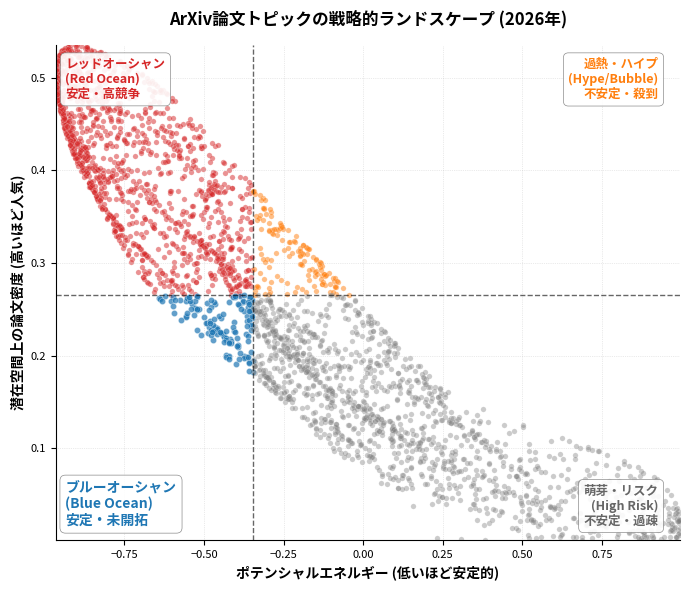

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析 (定義修正版)
# ============================================================
def evaluate_strategic_quadrants_jp_corrected(model, config, num_authors, device, year_idx=-1):
    """
    ArXiv論文データにおける研究トピックの戦略的ランドスケープ分析
    
    4象限の解釈:
    - 左下 (ブルーオーシャン): 安定 & 低密度 → 最有望・狙い目の研究領域
    - 左上 (レッドオーシャン): 安定 & 高密度 → 既存・飽和・激戦区
    - 右上 (過熱・ハイプ): 不安定 & 高密度 → バブル・流行・一時的トレンド
    - 右下 (萌芽・リスク): 不安定 & 低密度 → 探索・黎明期・ハイリスク
    
    Args:
        model: 学習済みモデル
        config: グラフデータを含む設定辞書
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス
    """
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（定義修正版）を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        # 次元数調整
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim 
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文(Paper)データのみ抽出
    # num_authors 以降のインデックスが論文ノード
    paper_z = z_np[num_authors:]
    paper_potentials = potentials[num_authors:]
    
    # --- 2. 密度推定 (KDE) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # サンプリング
    N_PLOT = 3000
    if len(paper_potentials) > N_PLOT:
        idx = np.random.choice(len(paper_potentials), N_PLOT, replace=False)
        plot_x = paper_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = paper_potentials
        plot_y = densities

    # --- 3. 4象限の分類ロジック (修正版) ---
    x_thr = np.median(plot_x) # ポテンシャル中央値
    y_thr = np.median(plot_y) # 密度中央値
    
    # 【左下】ブルーオーシャン (安定 & 低密度) -> 最有望・狙い目
    mask_blue = (plot_x <= x_thr) & (plot_y <= y_thr)
    
    # 【左上】レッドオーシャン (安定 & 高密度) -> 既存・飽和・激戦区
    mask_red = (plot_x <= x_thr) & (plot_y > y_thr)
    
    # 【右上】過熱・ハイプ (不安定 & 高密度) -> バブル・流行・一時的
    mask_hype = (plot_x > x_thr) & (plot_y > y_thr)
    
    # 【右下】萌芽・リスク (不安定 & 低密度) -> 探索・黎明期
    mask_risk = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 左上: レッドオーシャン (赤)
    ax.scatter(plot_x[mask_red], plot_y[mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (飽和)', edgecolors='white', linewidth=0.2)
    
    # 左下: ブルーオーシャン (青 - 最も目立たせる)
    ax.scatter(plot_x[mask_blue], plot_y[mask_blue], c='#1f77b4', s=20, alpha=0.7, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.3)
    
    # 右上: 過熱・ハイプ (オレンジ/黄色)
    ax.scatter(plot_x[mask_hype], plot_y[mask_hype], c='#ff7f0e', s=15, alpha=0.5, 
               label='過熱・ハイプ (バブル)', edgecolors='white', linewidth=0.2)
    
    # 右下: 萌芽・リスク (灰)
    ax.scatter(plot_x[mask_risk], plot_y[mask_risk], c='#7f7f7f', s=15, alpha=0.4, 
               label='萌芽・リスク (探索)', edgecolors='white', linewidth=0.2)

    # しきい値線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # ラベル配置 (ボックス付き)
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.5)
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 左上
    ax.text(x_min + (x_thr - x_min)*0.05, y_max - (y_max - y_thr)*0.05, 
            "レッドオーシャン\n(Red Ocean)\n安定・高競争", 
            fontsize=9, color='#d62728', fontweight='bold', bbox=box_props, ha='left', va='top')
            
    # 左下 (ここがターゲット)
    ax.text(x_min + (x_thr - x_min)*0.05, y_min + (y_thr - y_min)*0.05, 
            "ブルーオーシャン\n(Blue Ocean)\n安定・未開拓", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
            
    # 右上
    ax.text(x_max - (x_max - x_thr)*0.05, y_max - (y_max - y_thr)*0.05, 
            "過熱・ハイプ\n(Hype/Bubble)\n不安定・殺到", 
            fontsize=9, color='#ff7f0e', fontweight='bold', bbox=box_props, ha='right', va='top')
            
    # 右下
    ax.text(x_max - (x_max - x_thr)*0.05, y_min + (y_thr - y_min)*0.05, 
            "萌芽・リスク\n(High Risk)\n不安定・過疎", 
            fontsize=9, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸ラベル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の論文密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"ArXiv論文トピックの戦略的ランドスケープ ({target_year}年)", fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()

    # 保存
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/nature_strategy_landscape_jp_corrected.png', dpi=300)
    
    print("修正版プロットを保存しました: ./outputs/nature_strategy_landscape_jp_corrected.png")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        # 変数名の互換性チェック
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']  # 旧変数名との互換性
        else:
            n_authors = num_authors  # グローバル変数から取得
        
        evaluate_strategic_quadrants_jp_corrected(
            model, config, 
            num_authors=n_authors, 
            device=device
        )
    else:
        print("Model or config not loaded.")

,論文ID,象限,優先度,ポテンシャル,密度,安定性,競争度
766,1628,ブルーオーシャン,1,-0.658040,0.268499,High,Low
542,1404,ブルーオーシャン,1,-0.627746,0.260336,High,Low
558,1420,ブルーオーシャン,1,-0.619374,0.269490,High,Low
2524,3386,ブルーオーシャン,1,-0.615900,0.252620,High,Low
1349,2211,ブルーオーシャン,1,-0.614669,0.261747,High,Low
...,...,...,...,...,...,...,...
2716,3578,過熱・ハイプ,4,-0.100200,0.271657,Low,High
1632,2494,過熱・ハイプ,4,-0.088892,0.283605,Low,High
1941,2803,過熱・ハイプ,4,-0.083987,0.280974,Low,High
2648,3510,過熱・ハイプ,4,-0.077081,0.277851,Low,High


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch

def visualize_standard_ode_2d(model, data, num_corps, device, title="Standard ODE Vector Field"):
    """
    Standard GODE (物理なし) のベクトル場を可視化する関数
    PCAを用いて潜在空間を2次元に射影し、その平面上の「流れ」を描画します。
    """
    print(f"\n[Visualization] Generating Vector Field for {title}...")
    model.eval()
    data = data.to(device)
    
    # 1. データのエンコード
    with torch.no_grad():
        # 次元調整 (Padding)
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([x_input, padding], dim=1)
        
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. PCAで2次元平面を定義
    # 潜在変数が2次元より大きい場合に対応
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # 3. グリッドの作成
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    resolution = 30 # 矢印の密度
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    # 2Dグリッドを高次元空間に戻す (Inverse Transform)
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    # 4. ベクトル場 (ODEの微分値) の計算
    # dz/dt = f(z)
    with torch.no_grad():
        # StandardGODEは ode_func_module を持つ
        if hasattr(model, 'ode_func_module'):
            # 時間 t=0 で計算 (自律系なのでtは影響しないことが多い)
            dz_dt = model.ode_func_module(torch.tensor(0.0), grid_tensor)
        else:
            print("Error: Model does not have 'ode_func_module'. Is this StandardGODE?")
            return

    # 5. ベクトルを高次元から2Dへ射影
    # PCAの回転行列 (components_) を掛けて2D方向成分を取り出す
    dz_dt_np = dz_dt.cpu().numpy()
    dz_dt_2d = np.dot(dz_dt_np, pca.components_.T)
    
    U = dz_dt_2d[:, 0].reshape(X.shape)
    V = dz_dt_2d[:, 1].reshape(X.shape)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # A. ベクトル場 (Quiver)
    # 矢印の長さを調整
    speed = np.sqrt(U**2 + V**2)
    # 線幅を速度に比例させると見やすい
    lw = 0.5 + 1.5 * (speed / speed.max())
    
    ax.quiver(X, Y, U, V, color='gray', alpha=0.5, 
              angles='xy', scale_units='xy', scale=None, # 自動スケール
              width=0.002, headwidth=4, headlength=5)
    
    # B. 流線 (Streamplot) - 全体的な「流れ」を見るのに適している
    # ax.streamplot(X, Y, U, V, color=speed, cmap='viridis', linewidth=1, density=1.5, arrowsize=1.5)

    # C. データ点のプロット
    # 企業
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.6, s=20, 
               edgecolors='white', linewidth=0.5, label='Corporations')
    # 特許
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='red', alpha=0.2, s=10, 
               label='Patents')

    ax.set_title(title + "\n(No Potential Landscape)", fontsize=12, fontweight='bold')
    ax.set_xlabel('Latent Dim 1 (PCA)', fontsize=10)
    ax.set_ylabel('Latent Dim 2 (PCA)', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# --- 実行例 ---
if __name__ == "__main__":
    # StandardGODEモデルが 'model_standard' という名前で学習済みだと仮定
    # もし学習済みモデルがなければ、前回の train_comparison の返り値などを使用してください
    
    # 例: train_comparison で学習した StandardGODE モデルを取り出す場合
    # (train_comparison関数を少し修正して、学習済みモデル自体を返すようにする必要があります)
    
    # ここでは関数の使い方のイメージのみ提示します
    # visualize_standard_ode_2d(trained_standard_model, graphs[last_year], num_corps, device)
    pass


[Visualization] Generating RQ2 Landscape (3D + Vector Field)...
Visualization saved to ./outputs/


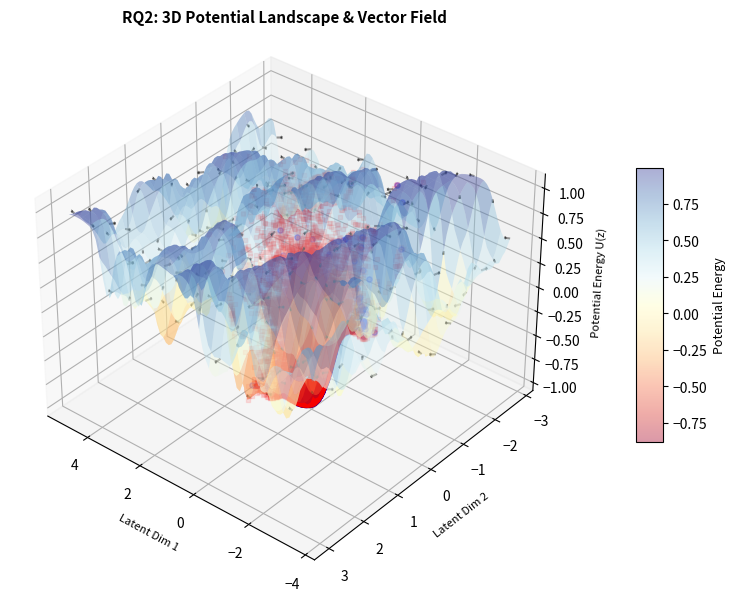

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import torch
from sklearn.decomposition import PCA

# ============================================================
# 1. Nature Style Configuration (3D + JP Fonts)
# ============================================================
def set_nature_style_3d():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 8,
        'axes.titlesize': 10,
        'legend.fontsize': 7,
        'savefig.dpi': 300,
        'figure.figsize': (6.0, 5.0), # 矢印が入るため少し余裕を持たせる
         'svg.fonttype': 'none', 
    })

# ============================================================
# 2. Main Visualization Function (3D Surface + Vector Field)
# ============================================================
def visualize_rq2_nature_3d_vectors(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style_3d()
    print("\n[Visualization] Generating RQ2 Landscape (3D + Vector Field)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    # --- 1. データ点のエンコードとポテンシャル取得 ---
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        # 次元調整 (Padding)
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        
        # 各ノードの高さ(ポテンシャル)を取得
        potentials_nodes = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # --- 2. PCA Projection (2D座標系を作る) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- 3. Grid & Gradient Calculation (ベクトル場の計算) ---
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    margin_factor = 0.2
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 80 # 計算用解像度
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # 勾配計算 (Autograd)
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    
    # 勾配をPCA空間(2D)へ射影
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    # ベクトル成分 (-勾配方向 = ポテンシャルが下がる方向)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # ================= Plotting 3D =================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. Surface Plot (地形)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', alpha=0.4, 
                           linewidth=0, antialiased=True, rstride=3, cstride=3)
    
    # B. Vector Field (Quiver) - 間引き処理
    # 全点描画すると真っ黒になるため、strideで間引く
    skip = 6 
    X_skip = X[::skip, ::skip]
    Y_skip = Y[::skip, ::skip]
    Z_skip = Z[::skip, ::skip]
    U_skip = U[::skip, ::skip]
    V_skip = V[::skip, ::skip]
    
    # 矢印の長さ調整 (正規化して一定の長さにすると見やすい場合と、強さを残す場合があります。ここでは強さを残しつつスケール調整)
    # Z方向成分(W)は0にして、等高線に沿った「水平方向の力」として描画するのが一般的で見やすいです
    ax.quiver(X_skip, Y_skip, Z_skip, U_skip, V_skip, np.zeros_like(Z_skip),
              length=0.15, normalize=True, color='black', alpha=0.4, arrow_length_ratio=0.3, label='Flow Field')

    # C. Scatter Plots (データ点)
    corp_x = z_2d[:num_corps, 0]
    corp_y = z_2d[:num_corps, 1]
    corp_z = potentials_nodes[:num_corps]
    
    patent_x = z_2d[num_corps:, 0]
    patent_y = z_2d[num_corps:, 1]
    patent_z = potentials_nodes[num_corps:]

    # 特許 (Patents) - 透明度 0.1
    ax.scatter(patent_x, patent_y, patent_z, 
               c='red', marker='s', s=5, 
               alpha=0.1, depthshade=False, # depthshade=Falseで色の濃さを距離に依存させない（透明度を厳密に適用）
               label='特許 (Patents)')

    # 企業 (Corporations) - 透明度 0.3
    ax.scatter(corp_x, corp_y, corp_z, 
               c='blue', marker='o', s=15, 
               alpha=0.3, depthshade=False,
               label='企業 (Corporations)')

    # D. Labels & View
    ax.set_title("RQ2: 3D Potential Landscape & Vector Field", fontsize=11, fontweight='bold')
    ax.set_xlabel("Latent Dim 1", fontsize=8)
    ax.set_ylabel("Latent Dim 2", fontsize=8)
    ax.set_zlabel("Potential Energy U(z)", fontsize=8)
    
    # 視点の初期設定 (見やすい角度)
    ax.view_init(elev=35, azim=130)

    # カラーバー
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    cbar.set_label('Potential Energy', fontsize=9)

    plt.tight_layout()
    
    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（プレビュー・確認用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.png',
        dpi=300
    )
    print(f"Visualization saved to ./outputs/")
    plt.show()

if __name__ == "__main__":
    visualize_rq2_nature_3d_vectors(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


[Evaluation] Verifying Attractor Validity (English Labels)...
Evaluation plot saved to ./outputs/
Correlation: -0.6818


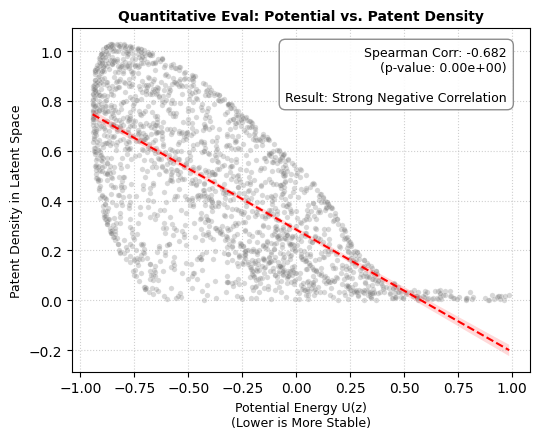

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_rq2_quantitative_english(model, config, num_corps, device, year_idx=-1):
    # スタイル設定（英語フォントのみ使用）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], # 標準的な英語フォント
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',   # SVGで文字をアウトライン化しない
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (English Labels)...")
    
    # 1. データ準備
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        return

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 2. 特許ノード抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 3. 密度推定
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except:
        return

    # 4. 相関計算
    corr, p_value = spearmanr(patent_potentials, densities)
    
    # 5. プロット（英語ラベル）
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    if len(patent_potentials) > 2000:
        idx = np.random.choice(len(patent_potentials), 2000, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = patent_potentials
        plot_y = densities
        alpha_val = 0.5
        
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', edgecolors='white', linewidth=0.3, label='Patents')
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # 英語タイトル・ラベル
    ax.set_title("Quantitative Eval: Potential vs. Patent Density", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Patent Density in Latent Space", fontsize=9)
    
    # 統計量テキスト
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n\n"
                  f"Result: Strong Negative Correlation")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（確認・レビュー用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.png',
        dpi=300
    )

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f}")
    plt.show()

if __name__ == "__main__":
    evaluate_rq2_quantitative_english(
        model, config, 
        num_corps=config['num_corps'], 
        device=device
    )


[Evaluation] 技術戦略マップ（日本語版）を作成中...
  Spearman Correlation: -0.8331
日本語版プロットを保存しました:
 - ./outputs/nature_strategy_landscape_jp.svg
 - ./outputs/nature_strategy_landscape_jp.png


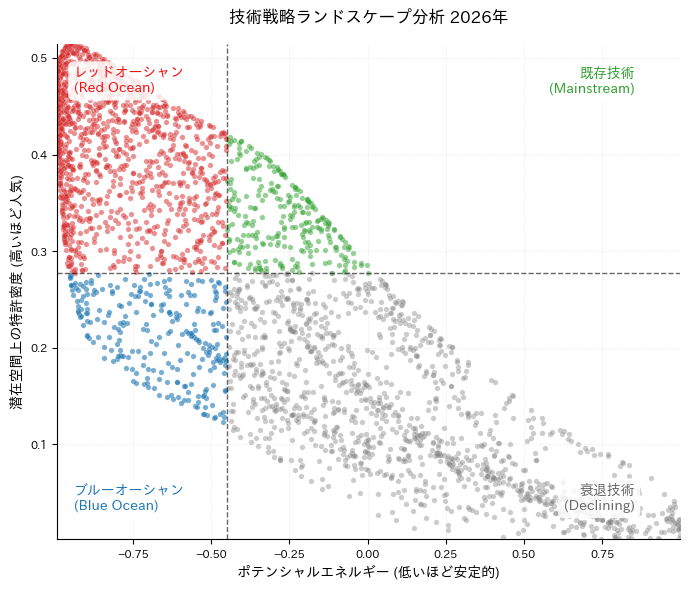

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        # 日本語フォントの優先順位設定
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (6, 5),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 戦略的4象限分析 (日本語版)
# ============================================================
def evaluate_strategic_quadrants_jp(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 技術戦略マップ（日本語版）を作成中...")
    
    # --- 1. データ準備と計算 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        # 次元数調整
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード & ポテンシャル計算
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許データのみ抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 密度推定 (KDE)
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # --- 2. サンプリング (描画負荷軽減) ---
    N_PLOT = 3000
    if len(patent_potentials) > N_PLOT:
        idx = np.random.choice(len(patent_potentials), N_PLOT, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = patent_potentials
        plot_y = densities

    # --- 3. 統計的評価 (Spearman相関) ---
    corr, p_value = spearmanr(patent_potentials, densities)
    print(f"  Spearman Correlation: {corr:.4f}")

    # --- 4. 4象限の分類ロジック ---
    # 中央値をしきい値とする
    x_thr = np.median(plot_x) # ポテンシャルしきい値
    y_thr = np.median(plot_y) # 密度しきい値
    
    # 1. ブルーオーシャン (左下: 安定 & 低密度) -> 最有望
    # ポテンシャルが低い(安定) かつ 密度が低い(空いている)
    mask_blue = (plot_x <= x_thr) & (plot_y <= y_thr)
    
    # 2. レッドオーシャン (左上: 安定 & 高密度) -> 成熟・必須
    # ポテンシャルが低い(安定) かつ 密度が高い(混んでいる)
    mask_red = (plot_x <= x_thr) & (plot_y > y_thr)
    
    # 3. 既存技術 (右上: 不安定 & 高密度) -> 過熱・激戦
    # ポテンシャルが高い(不安定) かつ 密度が高い(混んでいる)
    mask_main = (plot_x > x_thr) & (plot_y > y_thr)
    
    # 4. 衰退技術 (右下: 不安定 & 低密度) -> リスク・探索
    # ポテンシャルが高い(不安定) かつ 密度が低い(空いている)
    mask_decline = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 5. プロット ---
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 各象限の散布図描画
    # 既存技術 (緑)
    ax.scatter(plot_x[mask_main], plot_y[mask_main], c='#2ca02c', s=15, alpha=0.5, 
               label='既存技術 (安定・成熟)', edgecolors='white', linewidth=0.2)
    # ブルーオーシャン (青)
    ax.scatter(plot_x[mask_blue], plot_y[mask_blue], c='#1f77b4', s=15, alpha=0.6, 
               label='ブルーオーシャン (有望)', edgecolors='white', linewidth=0.2)
    # レッドオーシャン (赤)
    ax.scatter(plot_x[mask_red], plot_y[mask_red], c='#d62728', s=15, alpha=0.5, 
               label='レッドオーシャン (激戦)', edgecolors='white', linewidth=0.2)
    # 衰退技術 (灰)
    ax.scatter(plot_x[mask_decline], plot_y[mask_decline], c='#7f7f7f', s=15, alpha=0.4, 
               label='衰退技術 (不安定)', edgecolors='white', linewidth=0.2)

    # しきい値の線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # 象限ラベル (背景ボックス付き)
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='none')
    
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 左上: レッドオーシャン
    ax.text(x_min + (x_thr - x_min)*0.1, y_max - (y_max - y_thr)*0.1, 
            "レッドオーシャン\n(Red Ocean)", 
            fontsize=10, color="#F40D0D", fontweight='bold', bbox=box_props, ha='left', va='top')
            
    # 左下: ブルーオーシャン
    ax.text(x_min + (x_thr - x_min)*0.1, y_min + (y_thr - y_min)*0.1, 
            "ブルーオーシャン\n(Blue Ocean)", 
            fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
            
    # 右上: 既存技術
    ax.text(x_max - (x_max - x_thr)*0.1, y_max - (y_max - y_thr)*0.1, 
            "既存技術\n(Mainstream)", 
            fontsize=10, color='#2ca02c', fontweight='bold', bbox=box_props, ha='right', va='top')
            
    # 右下: 衰退技術
    ax.text(x_max - (x_max - x_thr)*0.1, y_min + (y_thr - y_min)*0.1, 
            "衰退技術\n(Declining)", 
            fontsize=10, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸ラベル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の特許密度 (高いほど人気)", fontsize=10, fontweight='bold')
    ax.set_title(f"技術戦略ランドスケープ分析 {target_year}年", fontsize=12, fontweight='bold', pad=15)
    
    # 軸範囲
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # グリッド
    ax.grid(True, linestyle=':', alpha=0.4)
    
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_strategy_landscape_jp.svg',
        format='svg',
        bbox_inches='tight'
    )
    
    # PNG（確認・スライド用）
    plt.savefig(
        './outputs/nature_strategy_landscape_jp.png',
        dpi=300
    )
    
    print("日本語版プロットを保存しました:")
    print(" - ./outputs/nature_strategy_landscape_jp.svg")
    print(" - ./outputs/nature_strategy_landscape_jp.png")
    plt.show()


# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        evaluate_strategic_quadrants_jp(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )
    else:
        print("Model or config not loaded.")

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_blue_ocean_papers(model, config, df, num_authors, device, year_idx=-1, top_k=20):
    """
    ブルーオーシャン象限（安定 & 低競争）に属する論文を抽出
    
    Args:
        model: 学習済みモデル
        config: グラフデータを含む設定辞書
        df: 元のDataFrame（URL、タイトル、著者情報などを含む）
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス
        top_k: 抽出する論文数（デフォルト: 20）
    
    Returns:
        DataFrame: ブルーオーシャン論文のリスト
    """
    print(f"\n[Analysis] ブルーオーシャン象限の論文を抽出中...")
    
    # --- 1. ポテンシャルと密度の計算 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return pd.DataFrame()

    with torch.no_grad():
        # 次元調整
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文ノードの抽出（num_authors以降）
    paper_indices = np.arange(num_authors, len(z_np))
    paper_z = z_np[paper_indices]
    paper_potentials = potentials[paper_indices]
    
    # 密度計算（KDE）
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        paper_densities = kde(z_2d.T)
    except Exception as e:
        print(f"密度計算エラー: {e}")
        return pd.DataFrame()

    # --- 2. ブルーオーシャン象限の判定 ---
    pot_threshold = np.median(paper_potentials)
    density_threshold = np.median(paper_densities)
    
    # ブルーオーシャン: 低ポテンシャル（安定） & 低密度（競争少ない）
    mask_blue = (paper_potentials <= pot_threshold) & (paper_densities <= density_threshold)
    
    blue_indices = np.where(mask_blue)[0]
    
    if len(blue_indices) == 0:
        print("ブルーオーシャン象限に該当する論文がありません。")
        return pd.DataFrame()
    
    print(f"ブルーオーシャン象限の論文数: {len(blue_indices)} 件")
    
    # --- 3. ポテンシャルが低い順（=最も安定）にソート ---
    sorted_indices = blue_indices[np.argsort(paper_potentials[blue_indices])][:top_k]
    
    # --- 4. 元のDataFrameから論文情報を取得 ---
    # config内に論文URLのリストがあると仮定
    paper_urls = config.get('papers', df['url'].unique().tolist())
    
    results = []
    for rank, idx in enumerate(sorted_indices, 1):
        if idx < len(paper_urls):
            paper_url = paper_urls[idx]
            
            # DataFrameから該当論文の情報を取得
            row = df[df['url'] == paper_url]
            if not row.empty:
                paper_info = row.iloc[0]
                
                # タイトル取得
                title = paper_info.get('title', 'No Title')
                if pd.isna(title) or title == "":
                    title = "タイトル情報なし"
                
                # 著者取得
                authors = paper_info.get('authors', '')
                if isinstance(authors, str):
                    # カンマ区切りの場合、最初の3名のみ表示
                    author_list = [a.strip() for a in authors.split(',')]
                    if len(author_list) > 3:
                        authors_display = ', '.join(author_list[:3]) + ' et al.'
                    else:
                        authors_display = ', '.join(author_list)
                else:
                    authors_display = str(authors)
                
                # 年取得
                year = paper_info.get('year', target_year)
                
                # 要約取得（あれば）
                abstract = paper_info.get('abstract', '')
                if pd.isna(abstract) or abstract == "":
                    abstract = "要約なし"
                else:
                    # 最初の150文字のみ
                    abstract = str(abstract)[:150] + "..." if len(str(abstract)) > 150 else str(abstract)
                
                results.append({
                    "順位": rank,
                    "論文URL": paper_url,
                    "タイトル": title,
                    "著者": authors_display,
                    "年": int(year) if not pd.isna(year) else target_year,
                    "ポテンシャル": f"{paper_potentials[idx]:.4f}",
                    "密度": f"{paper_densities[idx]:.4e}",
                    "安定度": "Very High" if paper_potentials[idx] < pot_threshold * 0.8 else "High",
                    "要約(抜粋)": abstract
                })
    
    df_blue_ocean = pd.DataFrame(results)
    
    # --- 5. 結果の表示と保存 ---
    print("\n" + "="*100)
    print(f"ブルーオーシャン象限トップ{top_k}論文 ({target_year}年)")
    print("="*100)
    
    # 表示設定
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', 60)
    pd.set_option('display.width', 1000)
    
    # 要約以外の列を先に表示
    display_cols = ["順位", "タイトル", "著者", "年", "ポテンシャル", "密度", "安定度"]
    print(df_blue_ocean[display_cols].to_string(index=False))
    print("="*100)
    
    # CSVとして保存
    df_blue_ocean.to_csv('./outputs/blue_ocean_papers.csv', index=False, encoding='utf-8-sig')
    print(f"\n詳細データを保存しました: ./outputs/blue_ocean_papers.csv")
    
    # 詳細版（要約付き）も表示
    print("\n【詳細情報（要約付き）】")
    for _, row in df_blue_ocean.iterrows():
        print(f"\n{row['順位']}. {row['タイトル']}")
        print(f"   著者: {row['著者']}")
        print(f"   年: {row['年']} | ポテンシャル: {row['ポテンシャル']} | 密度: {row['密度']}")
        print(f"   URL: {row['論文URL']}")
        print(f"   要約: {row['要約(抜粋)']}")
        print("-" * 100)
    
    return df_blue_ocean

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals() and 'df' in locals():
        # 変数名の互換性チェック
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']
        else:
            n_authors = num_authors
        
        # ブルーオーシャン論文を抽出
        df_blue_ocean = extract_blue_ocean_papers(
            model=model,
            config=config,
            df=df,
            num_authors=n_authors,
            device=device,
            top_k=20  # 上位20件
        )
        
        # Jupyter環境の場合は display で表示
        try:
            from IPython.display import display
            print("\n【DataFrameビュー】")
            display(df_blue_ocean[["順位", "タイトル", "著者", "年", "ポテンシャル", "密度"]])
        except:
            pass
            
    else:
        print("エラー: model, config, df が必要です。")
        print("前段のコードで学習とデータ読み込みを実行してください。")


[Analysis] ブルーオーシャン象限の論文を抽出中...
ブルーオーシャン象限の論文数: 381 件

ブルーオーシャン象限トップ20論文 (2026年)
 順位                                                                                                               タイトル                                                           著者    年  ポテンシャル         密度       安定度
  1                                                                                     Neural Volume Super-Resolution         Yuval Bahat, Yuxuan Zhang, Hendrik Sommerhoff et al. 2022 -0.6411 2.6204e-01 Very High
  2                              ERGNN: Spectral Graph Neural Network With Explicitly-Optimized Rational Graph Filters                       Guoming Li, Jian Yang, Shangsong Liang 2024 -0.6403 2.6176e-01 Very High
  3          3DProxyImg: Controllable 3D-Aware Animation Synthesis from Single Image via 2D-3D Aligned Proxy Embedding                  Yupeng Zhu, Xiongzhen Zhang, Ye Chen et al. 2025 -0.6374 2.6281e-01 Very High
  4                                                   NeRF-SR:

,順位,タイトル,著者,年,ポテンシャル,密度
0,1,Neural Volume Super-Resolution,"Yuval Bahat, Yuxuan Zhang, Hendrik Sommerhoff et al.",2022,-0.6411,2.6204e-01
1,2,ERGNN: Spectral Graph Neural Network With Explicitly-Opt...,"Guoming Li, Jian Yang, Shangsong Liang",2024,-0.6403,2.6176e-01
2,3,3DProxyImg: Controllable 3D-Aware Animation Synthesis fr...,"Yupeng Zhu, Xiongzhen Zhang, Ye Chen et al.",2025,-0.6374,2.6281e-01
3,4,NeRF-SR: High-Quality Neural Radiance Fields using Super...,"Chen Wang, Xian Wu, Yuan-Chen Guo et al.",2021,-0.6373,2.6098e-01
4,5,Reading or Reasoning? Format Decoupled Reinforcement Lea...,"Yufeng Zhong, Lei Chen, Zhixiong Zeng et al.",2025,-0.6368,2.6204e-01
5,6,RSAgent: Learning to Reason and Act for Text-Guided Segm...,"Xingqi He, Yujie Zhang, Shuyong Gao et al.",2025,-0.6307,2.5918e-01
6,7,Dual-Refinement: Joint Label and Feature Refinement for ...,"Yongxing Dai, Jun Liu, Yan Bai et al.",2020,-0.6284,2.6346e-01
7,8,ColaVLA: Leveraging Cognitive Latent Reasoning for Hiera...,"Qihang Peng, Xuesong Chen, Chenye Yang et al.",2025,-0.6277,2.6034e-01
8,9,Learning from Mistakes based on Class Weighting with App...,"Jay Gala, Pengtao Xie",2021,-0.6227,2.6402e-01
9,10,FreeInit: Bridging Initialization Gap in Video Diffusion...,"Tianxing Wu, Chenyang Si, Yuming Jiang et al.",2023,-0.6159,2.5262e-01


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_blue_ocean_papers(model, config, df, num_authors, device, year_idx=-1, top_k=20):
    """
    ブルーオーシャン象限（安定 & 低競争）に属する論文を抽出
    
    Args:
        model: 学習済みモデル
        config: グラフデータを含む設定辞書
        df: 元のDataFrame（URL、タイトル、著者情報などを含む）
        num_authors: 著者ノードの数
        device: torch device
        year_idx: 評価対象の年インデックス
        top_k: 抽出する論文数（デフォルト: 20）
    
    Returns:
        DataFrame: ブルーオーシャン論文のリスト
    """
    print(f"\n[Analysis] ブルーオーシャン象限の論文を抽出中...")
    
    # --- 1. ポテンシャルと密度の計算 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return pd.DataFrame()

    with torch.no_grad():
        # 次元調整
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim
        else:
            expected_dim = config['in_dim']
            
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        # エンコード
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文ノードの抽出（num_authors以降）
    paper_indices = np.arange(num_authors, len(z_np))
    paper_z = z_np[paper_indices]
    paper_potentials = potentials[paper_indices]
    
    # 密度計算（KDE）
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        paper_densities = kde(z_2d.T)
    except Exception as e:
        print(f"密度計算エラー: {e}")
        return pd.DataFrame()

    # --- 2. ブルーオーシャン象限の判定 ---
    pot_threshold = np.median(paper_potentials)
    density_threshold = np.median(paper_densities)
    
    # ブルーオーシャン: 低ポテンシャル（安定） & 低密度（競争少ない）
    mask_blue = (paper_potentials <= pot_threshold) & (paper_densities <= density_threshold)
    
    blue_indices = np.where(mask_blue)[0]
    
    if len(blue_indices) == 0:
        print("ブルーオーシャン象限に該当する論文がありません。")
        return pd.DataFrame()
    
    print(f"ブルーオーシャン象限の論文数: {len(blue_indices)} 件")
    
    # --- 3. ポテンシャルが低い順（=最も安定）にソート ---
    sorted_indices = blue_indices[np.argsort(paper_potentials[blue_indices])][:top_k]
    
    # --- 4. 元のDataFrameから論文情報を取得 ---
    # ArXivデータの場合、dfから直接URLリストを取得
    # df['url']の順序とグラフ構築時の論文順序が一致している前提
    
    # config内の論文リスト（グラフ構築時の順序）を使用
    if 'papers' in config:
        paper_urls = config['papers']  # build_author_paper_graphsで作成されたリスト
    else:
        # なければdfから取得（年でフィルタリング）
        year_df = df[df['year'] == target_year] if 'year' in df.columns else df
        paper_urls = year_df['url'].unique().tolist()
    
    results = []
    for rank, idx in enumerate(sorted_indices, 1):
        if idx < len(paper_urls):
            paper_url = paper_urls[idx]
            
            # DataFrameから該当論文の情報を取得
            row = df[df['url'] == paper_url]
            if not row.empty:
                paper_info = row.iloc[0]
                
                # タイトル取得
                title = paper_info.get('title', 'No Title')
                if pd.isna(title) or title == "":
                    title = "タイトル情報なし"
                
                # 著者取得
                authors = paper_info.get('authors', '')
                if isinstance(authors, str):
                    # カンマ区切りの場合、最初の3名のみ表示
                    author_list = [a.strip() for a in authors.split(',')]
                    if len(author_list) > 3:
                        authors_display = ', '.join(author_list[:3]) + ' et al.'
                    else:
                        authors_display = ', '.join(author_list)
                else:
                    authors_display = str(authors) if not pd.isna(authors) else "著者情報なし"
                
                # 年取得
                year = paper_info.get('year', target_year)
                
                # トピック取得（ArXivの場合は'topic'カラム）
                topics = paper_info.get('topic', '')
                if pd.isna(topics) or topics == "":
                    # categoriesカラムがある場合はそちらを使用
                    topics = paper_info.get('categories', '')
                if pd.isna(topics) or topics == "":
                    topics = "トピック情報なし"
                else:
                    # カンマ区切りの場合、最初の3つのみ表示
                    if isinstance(topics, str):
                        topic_list = [t.strip() for t in topics.split(',')]
                        if len(topic_list) > 3:
                            topics_display = ', '.join(topic_list[:3]) + '...'
                        else:
                            topics_display = ', '.join(topic_list)
                    else:
                        topics_display = str(topics)
                
                # 要約取得（descriptionカラムを使用）
                abstract = paper_info.get('description', '')
                if pd.isna(abstract) or abstract == "":
                    abstract = paper_info.get('abstract', '')
                if pd.isna(abstract) or abstract == "":
                    abstract = "要約なし"
                else:
                    # 最初の150文字のみ
                    abstract = str(abstract)[:150] + "..." if len(str(abstract)) > 150 else str(abstract)
                
                results.append({
                    "順位": rank,
                    "論文URL": paper_url,
                    "タイトル": title,
                    "著者": authors_display,
                    "年": int(year) if not pd.isna(year) else target_year,
                    "トピック": topics_display if 'topics_display' in locals() else str(topics),
                    "ポテンシャル": f"{paper_potentials[idx]:.4f}",
                    "密度": f"{paper_densities[idx]:.4e}",
                    "安定度": "Very High" if paper_potentials[idx] < pot_threshold * 0.8 else "High",
                    "要約(抜粋)": abstract
                })
            else:
                # DataFrameに該当URLがない場合（デバッグ用）
                print(f"警告: URL '{paper_url}' がDataFrameに見つかりません（スキップ）")
    
    df_blue_ocean = pd.DataFrame(results)
    
    # --- 5. 結果の表示と保存 ---
    print("\n" + "="*100)
    print(f"ブルーオーシャン象限トップ{top_k}論文 ({target_year}年)")
    print("="*100)
    
    # 表示設定
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', 60)
    pd.set_option('display.width', 1000)
    
    # 要約以外の列を先に表示
    display_cols = ["順位", "タイトル", "著者", "年", "トピック", "ポテンシャル", "密度", "安定度"]
    print(df_blue_ocean[display_cols].to_string(index=False))
    print("="*100)
    
    # CSVとして保存
    df_blue_ocean.to_csv('./outputs/blue_ocean_papers.csv', index=False, encoding='utf-8-sig')
    print(f"\n詳細データを保存しました: ./outputs/blue_ocean_papers.csv")
    
    # 詳細版（要約付き）も表示
    print("\n【詳細情報（要約付き）】")
    for _, row in df_blue_ocean.iterrows():
        print(f"\n{row['順位']}. {row['タイトル']}")
        print(f"   著者: {row['著者']}")
        print(f"   年: {row['年']} | トピック: {row['トピック']}")
        print(f"   ポテンシャル: {row['ポテンシャル']} | 密度: {row['密度']} | 安定度: {row['安定度']}")
        print(f"   URL: {row['論文URL']}")
        print(f"   要約: {row['要約(抜粋)']}")
        print("-" * 100)
    
    return df_blue_ocean

# ============================================================
# 実行ブロック
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals() and 'df' in locals():
        # 変数名の互換性チェック
        if 'num_authors' in config:
            n_authors = config['num_authors']
        elif 'num_corps' in config:
            n_authors = config['num_corps']
        else:
            n_authors = num_authors
        
        # ブルーオーシャン論文を抽出
        df_blue_ocean = extract_blue_ocean_papers(
            model=model,
            config=config,
            df=df,
            num_authors=n_authors,
            device=device,
            top_k=20  # 上位20件
        )
        
        # Jupyter環境の場合は display で表示
        try:
            from IPython.display import display
            print("\n【DataFrameビュー】")
            display(df_blue_ocean[["順位", "タイトル", "著者", "年", "トピック", "ポテンシャル", "密度"]])
        except:
            pass
            
    else:
        print("エラー: model, config, df が必要です。")
        print("前段のコードで学習とデータ読み込みを実行してください。")


[Analysis] ブルーオーシャン象限の論文を抽出中...
ブルーオーシャン象限の論文数: 381 件

ブルーオーシャン象限トップ20論文 (2026年)
 順位                                                                      タイトル                                               著者    年  トピック  ポテンシャル         密度       安定度
  7 Wavelet-Driven Masked Multiscale Reconstruction for PPG Foundation Models Megha Thukral, Cyrus Tanade, Simon A. Lee et al. 2026 cs.LG -0.6284 2.6346e-01 Very High

詳細データを保存しました: ./outputs/blue_ocean_papers.csv

【詳細情報（要約付き）】

7. Wavelet-Driven Masked Multiscale Reconstruction for PPG Foundation Models
   著者: Megha Thukral, Cyrus Tanade, Simon A. Lee et al.
   年: 2026 | トピック: cs.LG
   ポテンシャル: -0.6284 | 密度: 2.6346e-01 | 安定度: Very High
   URL: http://arxiv.org/abs/2601.12215v1
   要約: Wearable foundation models have the potential to transform digital health by learning transferable representations from large-scale biosignals collect...
----------------------------------------------------------------------------------------------------

【DataF

,順位,タイトル,著者,年,トピック,ポテンシャル,密度
0,7,Wavelet-Driven Masked Multiscale Reconstruction for PPG ...,"Megha Thukral, Cyrus Tanade, Simon A. Lee et al.",2026,cs.LG,-0.6284,2.6346e-01


In [26]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def analyze_2026_with_topics(model, config, df, num_authors, device, top_k=5):
    print(f"\n[Analysis] 2026年度 象限分析（トピック付き）を実行中...")

    # --- 1. 年とデータの確認 ---
    target_year = 2026
    if target_year not in config['graphs']:
        print(f"エラー: {target_year}年のグラフデータがありません。")
        return None
    
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ノード数の確認
    total_nodes = data.x.shape[0]
    num_papers_in_graph = total_nodes - num_authors

    # --- 2. 推論 (ポテンシャル・密度) ---
    if hasattr(model, 'temporal_predictor'):
        pot_net = model.temporal_predictor.potential_net
    else:
        pot_net = model.potential_net

    with torch.no_grad():
        if hasattr(model, 'author_embeddings'):
            expected_dim = model.author_embeddings.embedding_dim
        else:
            expected_dim = config['in_dim']
        
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([x_input, padding], dim=1)
        
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 論文部分のみスライス
    paper_z = z_np[num_authors:] 
    paper_potentials = potentials[num_authors:]
    
    # 密度計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(paper_z)
    try:
        kde = gaussian_kde(z_2d.T)
        paper_densities = kde(z_2d.T)
    except:
        paper_densities = np.zeros_like(paper_potentials)

    # --- 3. URLリストの準備 ---
    df_year = df[df['year'] == target_year]
    paper_urls = df_year['url'].unique().tolist()
    
    limit = min(len(paper_urls), num_papers_in_graph)

    # --- 4. 象限分析と抽出 ---
    pot_med = np.median(paper_potentials)
    den_med = np.median(paper_densities)

    quadrants = {
        "Blue Ocean (安定・ニッチ)": (paper_potentials[:limit] <= pot_med) & (paper_densities[:limit] <= den_med),
        "Red Ocean (安定・激戦区)": (paper_potentials[:limit] <= pot_med) & (paper_densities[:limit] > den_med),
        "Frontier (不安定・ニッチ)": (paper_potentials[:limit] > pot_med) & (paper_densities[:limit] <= den_med),
        "Trend (不安定・激戦区)": (paper_potentials[:limit] > pot_med) & (paper_densities[:limit] > den_med),
    }

    all_results = []
    
    for q_name, mask in quadrants.items():
        indices = np.where(mask)[0]
        if len(indices) == 0: continue

        # ソート基準: 競争が激しい象限は密度順、ニッチな象限はポテンシャル順
        if "Red" in q_name or "Trend" in q_name:
            sorted_args = np.argsort(paper_densities[indices])[::-1] # 降順
        else:
            sorted_args = np.argsort(paper_potentials[indices])      # 昇順
            
        top_indices = indices[sorted_args][:top_k]
        
        for rank, idx in enumerate(top_indices, 1):
            url = paper_urls[idx]
            
            # 詳細情報の取得
            row = df[df['url'] == url]
            if not row.empty:
                info = row.iloc[0]
                title = info.get('title', 'No Title')
                
                # 著者
                authors = info.get('authors', '')
                if isinstance(authors, str):
                    auth_disp = authors.split(',')[0] + " et al."
                else:
                    auth_disp = str(authors)[:15]
                
                # ★トピック取得のロジック追加★
                topics = info.get('topic', '')
                if pd.isna(topics) or topics == "":
                    topics = info.get('categories', 'Unknown') # topicがなければcategoriesを見る
                
                # 長すぎる場合は省略
                topics_str = str(topics)
                if len(topics_str) > 25:
                    topics_disp = topics_str[:25] + "..."
                else:
                    topics_disp = topics_str

                all_results.append({
                    "象限": q_name,
                    "ランク": rank,
                    "タイトル": str(title)[:35] + "...", # タイトルも見やすく短縮
                    "トピック": topics_disp,            # 追加したカラム
                    "著者": auth_disp,
                    "ポテンシャル": f"{paper_potentials[idx]:.4f}",
                    "密度": f"{paper_densities[idx]:.2e}",
                    # "URL": url # 表示スペース節約のため今回は非表示（必要ならコメントアウト解除）
                })

    if not all_results:
        print("結果: 条件に合う論文が見つかりませんでした。")
        return pd.DataFrame()

    return pd.DataFrame(all_results)

# --- 実行ブロック ---
if 'config' in locals() and 'model' in locals():
    n_auth = config.get('num_authors', config.get('num_corps', 0))
    
    # 実行
    df_result = analyze_2026_with_topics(model, config, df, n_auth, device, top_k=5)
    
    if df_result is not None and not df_result.empty:
        print("\n【2026年度 象限別 注目論文リスト (Topic付)】")
        try:
            from IPython.display import display
            # 象限ごとにテーブルを表示
            for q in df_result['象限'].unique():
                print(f"\n### {q}")
                # 象限カラムを除いて表示（タイトルとして出しているため）
                display(df_result[df_result['象限'] == q].drop(columns=['象限']))
        except:
            print(df_result)


[Analysis] 2026年度 象限分析（トピック付き）を実行中...

【2026年度 象限別 注目論文リスト (Topic付)】

### Blue Ocean (安定・ニッチ)


,ランク,タイトル,トピック,著者,ポテンシャル,密度
0,1,Wavelet-Driven Masked Multiscale Re...,cs.LG,Megha Thukral et al.,-0.6284,2.63e-01
1,2,PlaM: Training-Free Plateau-Guided ...,cs.CL,Zijing Wang et al.,-0.5833,2.56e-01
2,3,Shape-morphing programming of soft ...,cs.LG,Lu Chen et al.,-0.5832,2.56e-01
3,4,How Order-Sensitive Are LLMs? Order...,cs.CL,Yingjie He et al.,-0.5762,2.60e-01
4,5,Learning to Factorize and Adapt: A ...,cs.LG,Siru Zhong et al.,-0.5734,2.38e-01



### Red Ocean (安定・激戦区)


,ランク,タイトル,トピック,著者,ポテンシャル,密度
5,1,MITRA: A Large-Scale Parallel Corpu...,cs.CL,Sebastian Nehrdich et al.,-0.8982,5.32e-01
6,2,OctoBench: Benchmarking Scaffold-Aw...,cs.CL,Deming Ding et al.,-0.8686,5.32e-01
7,3,ArcAligner: Adaptive Recursive Alig...,cs.CL,Jianbo Li et al.,-0.9376,5.32e-01
8,4,Unified Text-Image Generation with ...,cs.CV,Jiahui Chen et al.,-0.9192,5.32e-01
9,5,A Two-Stage GPU Kernel Tuner Combin...,cs.CL,Qiuyi Qu et al.,-0.9369,5.32e-01



### Frontier (不安定・ニッチ)


,ランク,タイトル,トピック,著者,ポテンシャル,密度
10,1,SERM: Self-Evolving Relevance Model...,cs.CL,Chenglong Wang et al.,-0.3478,2.60e-01
11,2,TRIM: Hybrid Inference via Targeted...,cs.AI,Vansh Kapoor et al.,-0.3458,1.94e-01
12,3,Mechanism Design for Federated Lear...,cs.GT,Xiang Li et al.,-0.3457,1.82e-01
13,4,VeRPO: Verifiable Dense Reward Poli...,cs.LG,Longwen Wang et al.,-0.3431,2.46e-01
14,5,Adversarial Alignment: Ensuring Val...,cs.CL,Yuan Gao et al.,-0.3416,1.79e-01



### Trend (不安定・激戦区)


,ランク,タイトル,トピック,著者,ポテンシャル,密度
15,1,CD^2: Constrained Dataset Distillat...,cs.CV,Kexin Bao et al.,-0.3144,3.64e-01
16,2,AFTER: Mitigating the Object Halluc...,cs.CV,Tianbo Wang et al.,-0.3334,3.56e-01
17,3,ASBA: A-line State Space Model and ...,cs.CV,Zhenghong Li et al.,-0.3339,3.47e-01
18,4,3D-Agent:Tri-Modal Multi-Agent Coll...,cs.CV,Jusheng Zhang et al.,-0.2569,3.47e-01
19,5,Large Language Models Are Bad Dice ...,cs.CL,Minda Zhao et al.,-0.3132,3.46e-01


In [28]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def analyze_topic_growth(model, config, df, num_authors, device, start_year, end_year):
    print(f"\n[Analysis] トピック成長分析: {start_year}年 -> {end_year}年")
    
    # --- 内部関数: その年の全論文の指標とトピック情報を取得 ---
    def get_paper_metrics(target_year):
        if target_year not in config['graphs']:
            return None
            
        data = config['graphs'][target_year].to(device)
        model.eval()
        
        # ポテンシャル予測
        if hasattr(model, 'temporal_predictor'):
            pot_net = model.temporal_predictor.potential_net
        else:
            pot_net = model.potential_net

        with torch.no_grad():
            if hasattr(model, 'author_embeddings'):
                expected_dim = model.author_embeddings.embedding_dim
            else:
                expected_dim = config['in_dim']
            
            x_input = data.x
            # パディング処理
            if x_input.shape[1] != expected_dim:
                padding = torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            
            z, _, _ = model.encode(x_input, data.edge_index)
            potentials = pot_net(z).squeeze().cpu().numpy()
            z_np = z.cpu().numpy()

        # 論文部分のみ抽出
        # ※ノード数が異なる場合があるため、安全にスライス
        paper_z = z_np[num_authors:]
        paper_pots = potentials[num_authors:]
        
        # 密度計算
        pca = PCA(n_components=2)
        if len(paper_z) > 5: # データが少なすぎるとPCA/KDEでエラーになるため
            z_2d = pca.fit_transform(paper_z)
            try:
                kde = gaussian_kde(z_2d.T)
                paper_dens = kde(z_2d.T)
            except:
                paper_dens = np.zeros_like(paper_pots)
        else:
            paper_dens = np.zeros_like(paper_pots)

        # DataFrameからURLリストを取得（順序を合わせる）
        # ※ここが重要: グラフ構築時の順序とDataFrameのURL順序を一致させる前提
        df_year = df[df['year'] == target_year]
        paper_urls = df_year['url'].unique().tolist()
        
        # 長さを揃える（グラフノード数とURLリスト数の小さい方に合わせる）
        min_len = min(len(paper_pots), len(paper_urls))
        
        results = []
        for i in range(min_len):
            url = paper_urls[i]
            # トピック情報の取得
            row = df[df['url'] == url]
            if not row.empty:
                topic_raw = row.iloc[0].get('topic', row.iloc[0].get('categories', 'Unknown'))
                # トピックがカンマ区切りの場合、分解してリスト化
                if isinstance(topic_raw, str):
                    topics = [t.strip() for t in topic_raw.split(',')]
                else:
                    topics = ['Unknown']
                
                for t in topics:
                    if t and t != 'Unknown':
                        results.append({
                            'Topic': t,
                            'Potential': paper_pots[i],
                            'Density': paper_dens[i],
                            'Year': target_year
                        })
        
        return pd.DataFrame(results)

    # --- 1. 両方の年のデータを取得・集計 ---
    df_metrics_start = get_paper_metrics(start_year)
    df_metrics_end = get_paper_metrics(end_year)
    
    if df_metrics_start is None or df_metrics_end is None:
        print("エラー: 指定された年のデータ取得に失敗しました。")
        return pd.DataFrame()

    if df_metrics_start.empty or df_metrics_end.empty:
        print("エラー: トピック情報の抽出に失敗しました（データが空です）。")
        return pd.DataFrame()

    # --- 2. トピックごとの集計（平均密度、論文数） ---
    def aggregate_topics(df_m):
        return df_m.groupby('Topic').agg({
            'Density': 'mean',
            'Potential': 'mean',
            'Topic': 'count' # 論文数
        }).rename(columns={'Topic': 'Count'})

    agg_start = aggregate_topics(df_metrics_start)
    agg_end = aggregate_topics(df_metrics_end)
    
    # 列名変更
    agg_start.columns = [f"{c}_{start_year}" for c in agg_start.columns]
    agg_end.columns = [f"{c}_{end_year}" for c in agg_end.columns]

    # --- 3. 結合して変化を計算 ---
    # 両方の年に存在するトピックのみ（あるいは新規出現も見たい場合はouter join）
    merged = pd.merge(agg_start, agg_end, on='Topic', how='inner')
    
    # 成長率などの計算
    merged['Count_Growth'] = merged[f'Count_{end_year}'] - merged[f'Count_{start_year}']
    merged['Density_Change'] = merged[f'Density_{end_year}'] - merged[f'Density_{start_year}']
    
    # --- 4. フィルタリング: 「過去はニッチ、今はメジャー」 ---
    # 条件:
    # 1. 論文数が大幅に増えた (Count Growth > 0)
    # 2. 密度が上昇した (Density Change > 0)
    # 3. 過去の論文数は少なめだった (例: 平均以下) -> 必須ではないが傾向として
    
    # 論文数が増加した順にソート
    df_growth = merged.sort_values('Count_Growth', ascending=False)
    
    # 表示用整形
    display_cols = [
        f'Count_{start_year}', f'Count_{end_year}', 'Count_Growth',
        f'Density_{start_year}', f'Density_{end_year}', 'Density_Change'
    ]
    
    # フォーマット調整
    pd.options.display.float_format = '{:.4f}'.format

    print("\n" + "="*100)
    print(f"【トピック急成長ランキング】 ({start_year} -> {end_year})")
    print(f"対象: 論文数と競争密度(Density)が共に上昇した分野")
    print("="*100)
    
    # フィルタ: 少なくとも1件以上増えていて、密度も上がっているもの
    hot_topics = df_growth[
        (df_growth['Count_Growth'] > 0) & 
        (df_growth['Density_Change'] > 0)
    ]
    
    if not hot_topics.empty:
        # 上位20件を表示
        try:
            from IPython.display import display
            display(hot_topics[display_cols].head(20))
        except:
            print(hot_topics[display_cols].head(20).to_string())
            
        return hot_topics
    else:
        print("条件に合致する急成長トピックが見つかりませんでした。")
        return df_growth

# --- 実行 ---
if 'config' in locals() and 'model' in locals():
    years = sorted(config['graphs'].keys())
    # 例: 2020年と2026年を比較
    # データセットにある最も古い年と新しい年を自動選択
    s_year = 2020 if 2020 in years else years[0]
    e_year = 2026 if 2026 in years else years[-1]
    
    if s_year != e_year:
        df_topics = analyze_topic_growth(
            model, config, df, 
            config.get('num_authors', config.get('num_corps', 0)), 
            device, 
            start_year=s_year, 
            end_year=e_year
        )
    else:
        print("比較可能な異なる年がありません。")


[Analysis] トピック成長分析: 2020年 -> 2026年

【トピック急成長ランキング】 (2020 -> 2026)
対象: 論文数と競争密度(Density)が共に上昇した分野


,Count_2020,Count_2026,Count_Growth,Density_2020,Density_2026,Density_Change
Topic,,,,,,
cs.CL,193,297,104,0.1615,0.2593,0.0978
cs.AI,15,50,35,0.1418,0.2632,0.1214
cs.SE,1,9,8,0.0819,0.2472,0.1653
cs.CR,5,9,4,0.1884,0.2429,0.0545
cs.RO,18,22,4,0.1447,0.2826,0.1379
cs.GT,1,2,1,0.0213,0.1089,0.0876
cs.NI,3,4,1,0.0647,0.2586,0.1940
cs.SD,10,11,1,0.2614,0.3019,0.0405



[Visualization] 全トピックのトレンド図を作成中 (gridモード)...
  > 総トピック数: 28
  > 表示対象トピック数 (合計5件以上): 22


<Figure size 1600x1800 with 0 Axes>

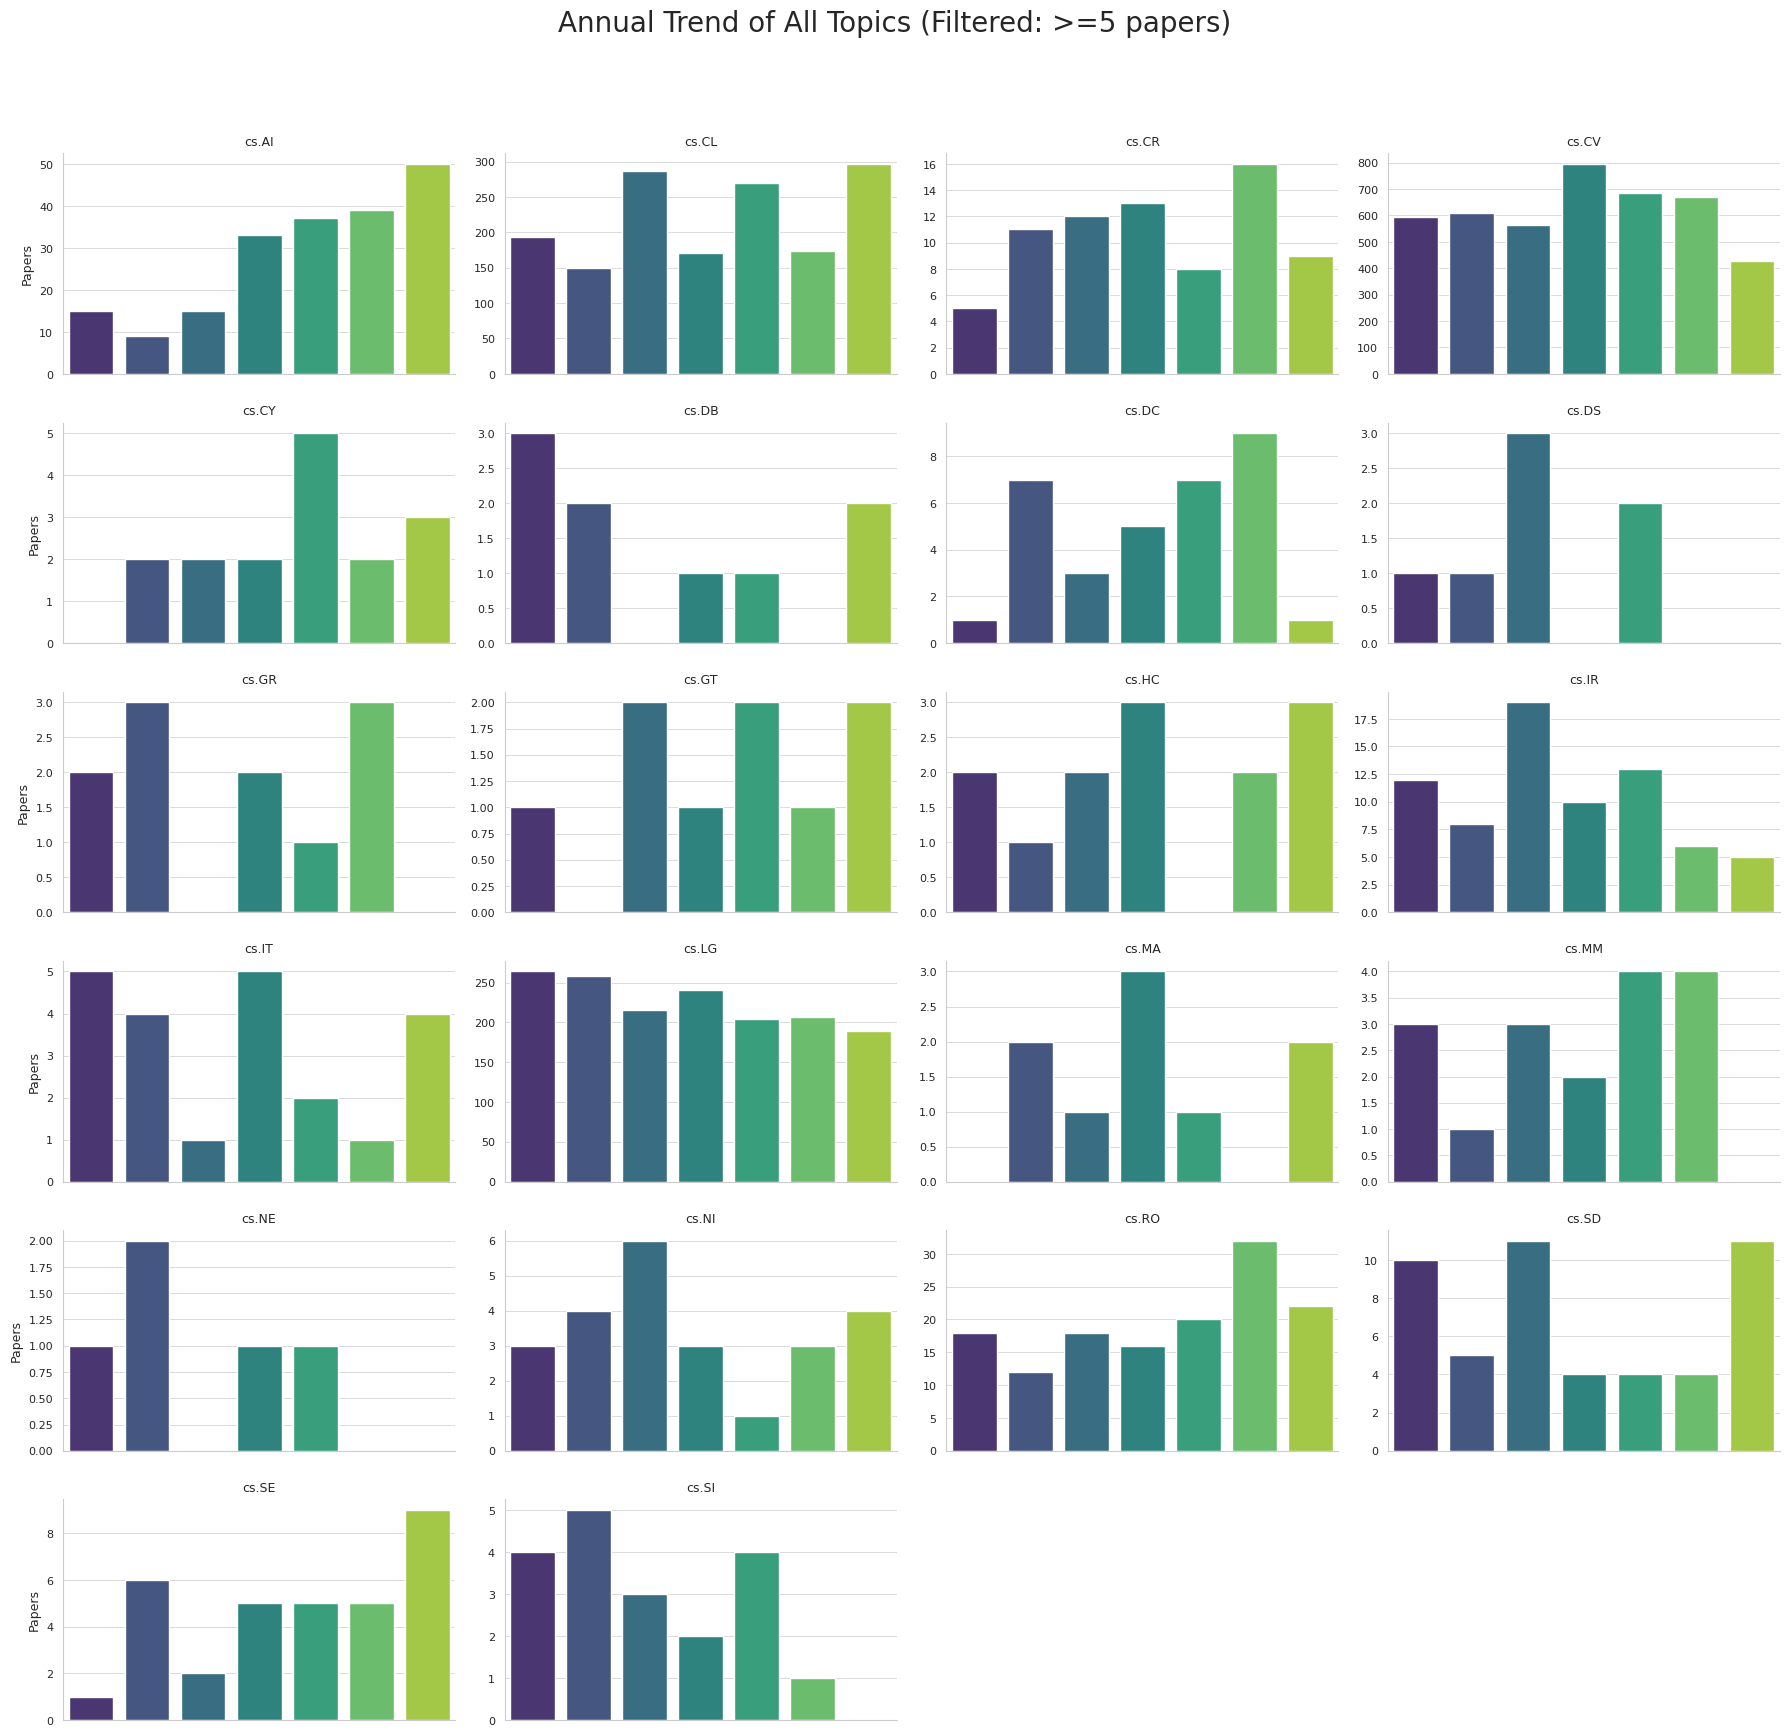

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

def visualize_all_topics_grid(df, min_total_papers=3, mode='grid'):
    """
    全トピックの年次推移を可視化する
    
    Args:
        df: DataFrame
        min_total_papers: 全期間合計でこれ以下の論文数のトピックは除外（ノイズ除去）
        mode: 'grid' (ヒストグラムを並べる) または 'heatmap' (ヒートマップで一覧)
    """
    print(f"\n[Visualization] 全トピックのトレンド図を作成中 ({mode}モード)...")

    # --- 1. データ整形 ---
    # トピックの展開とクリーニング
    df_exploded = df.assign(topic=df['topic'].str.split(',')).explode('topic')
    df_exploded['topic'] = df_exploded['topic'].str.strip()
    
    # 無効なトピックを除外
    df_clean = df_exploded[
        (df_exploded['topic'].notna()) & 
        (df_exploded['topic'] != "") & 
        (df_exploded['topic'] != "nan") & 
        (df_exploded['topic'] != "Unknown")
    ]

    # --- 2. ノイズ除去 ---
    # あまりに論文数が少ない（例: 合計3件以下）トピックは表示しても意味が薄いため除外
    topic_counts = df_clean['topic'].value_counts()
    valid_topics = topic_counts[topic_counts >= min_total_papers].index.tolist()
    
    df_filtered = df_clean[df_clean['topic'].isin(valid_topics)].copy()
    
    print(f"  > 総トピック数: {len(topic_counts)}")
    print(f"  > 表示対象トピック数 (合計{min_total_papers}件以上): {len(valid_topics)}")

    # 年ごとの集計
    trend_data = df_filtered.groupby(['topic', 'year']).size().reset_index(name='count')

    # --- 3. 可視化: グリッド形式 (ヒストグラム一覧) ---
    if mode == 'grid':
        # トピック数に応じた列数・行数の計算
        n_topics = len(valid_topics)
        n_cols = 4  # 横に並べる数
        n_rows = math.ceil(n_topics / n_cols)
        
        # グラフ全体のサイズ設定
        plt.figure(figsize=(16, 3 * n_rows))
        sns.set_style("whitegrid")
        
        # FacetGridを使ってトピックごとにサブプロットを作成
        g = sns.FacetGrid(
            trend_data, 
            col="topic", 
            col_wrap=n_cols, 
            sharex=True, 
            sharey=False,  # Y軸（件数）はトピックごとにスケールさせる（形状を見るため）
            height=3, 
            aspect=1.5
        )
        
        # 棒グラフを描画
        g.map(sns.barplot, "year", "count", order=sorted(trend_data['year'].unique()), palette="viridis")
        
        # タイトルや軸の調整
        g.set_titles("{col_name}") # トピック名をタイトルに
        g.set_axis_labels("", "Papers")
        
        # X軸ラベルの回転（重なり防止）
        for axes in g.axes.flat:
            _ = axes.set_xticklabels(axes.get_xticklabels(), rotation=45)

        plt.subplots_adjust(top=0.9)
        g.fig.suptitle(f'Annual Trend of All Topics (Filtered: >={min_total_papers} papers)', fontsize=20)
        
        plt.show()

    # --- 4. 可視化: ヒートマップ形式 (大量にある場合に見やすい) ---
    elif mode == 'heatmap':
        # ピボットテーブル作成 (行: トピック, 列: 年, 値: 件数)
        pivot_df = trend_data.pivot(index='topic', columns='year', values='count').fillna(0)
        
        # 合計数が多い順にソート
        pivot_df['total'] = pivot_df.sum(axis=1)
        pivot_df = pivot_df.sort_values('total', ascending=False).drop(columns=['total'])
        
        plt.figure(figsize=(12, max(8, len(valid_topics) * 0.4))) # トピック数に応じて縦長に
        
        sns.heatmap(
            pivot_df, 
            cmap="YlOrRd", # 黄色→赤
            annot=True,    # 数字を表示
            fmt='g',       # 整数表示
            linewidths=.5,
            cbar_kws={'label': 'Number of Papers'}
        )
        
        plt.title(f'Heatmap of Topic Trends (Sorted by Volume)', fontsize=16)
        plt.xlabel('Year')
        plt.ylabel('Topic')
        plt.show()

# --- 実行 ---
if 'df' in locals():
    # mode='grid' でヒストグラム一覧を表示
    # トピックが多すぎる場合は min_total_papers を上げて調整してください
    visualize_all_topics_grid(df, min_total_papers=5, mode='grid')
    
    # ヒートマップで見たい場合はこちら
    # visualize_all_topics_grid(df, min_total_papers=5, mode='heatmap')